# Print Results

In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import torch
import deepinv as dinv
from deepinv.physics import Denoising, GaussianNoise, PoissonNoise
from deepinv.utils.demo import load_url_image, get_image_url
from deepinv.utils.plotting import plot

from opt_functions.plot_results import *
from opt_functions.Solver_functions.white_opt_princ import *
        
import ISM.simulation.PSF_sim as ism
import ISM.analysis.Graph_lib as gr

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

Using device: cuda


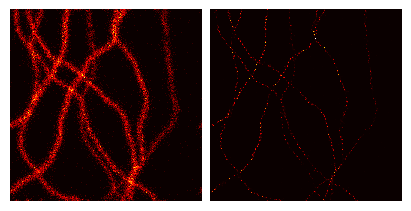

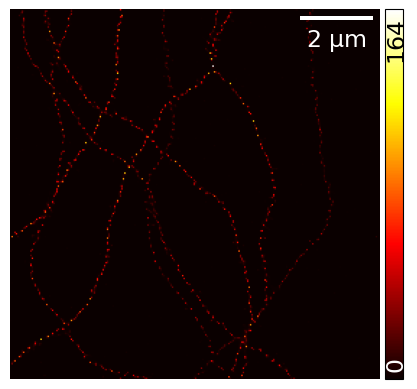

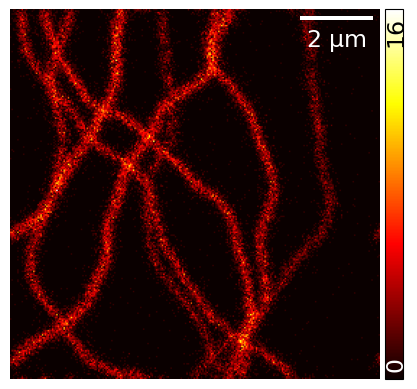

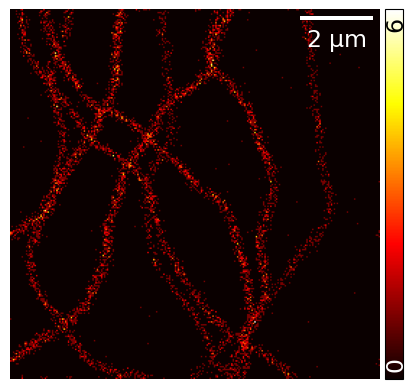

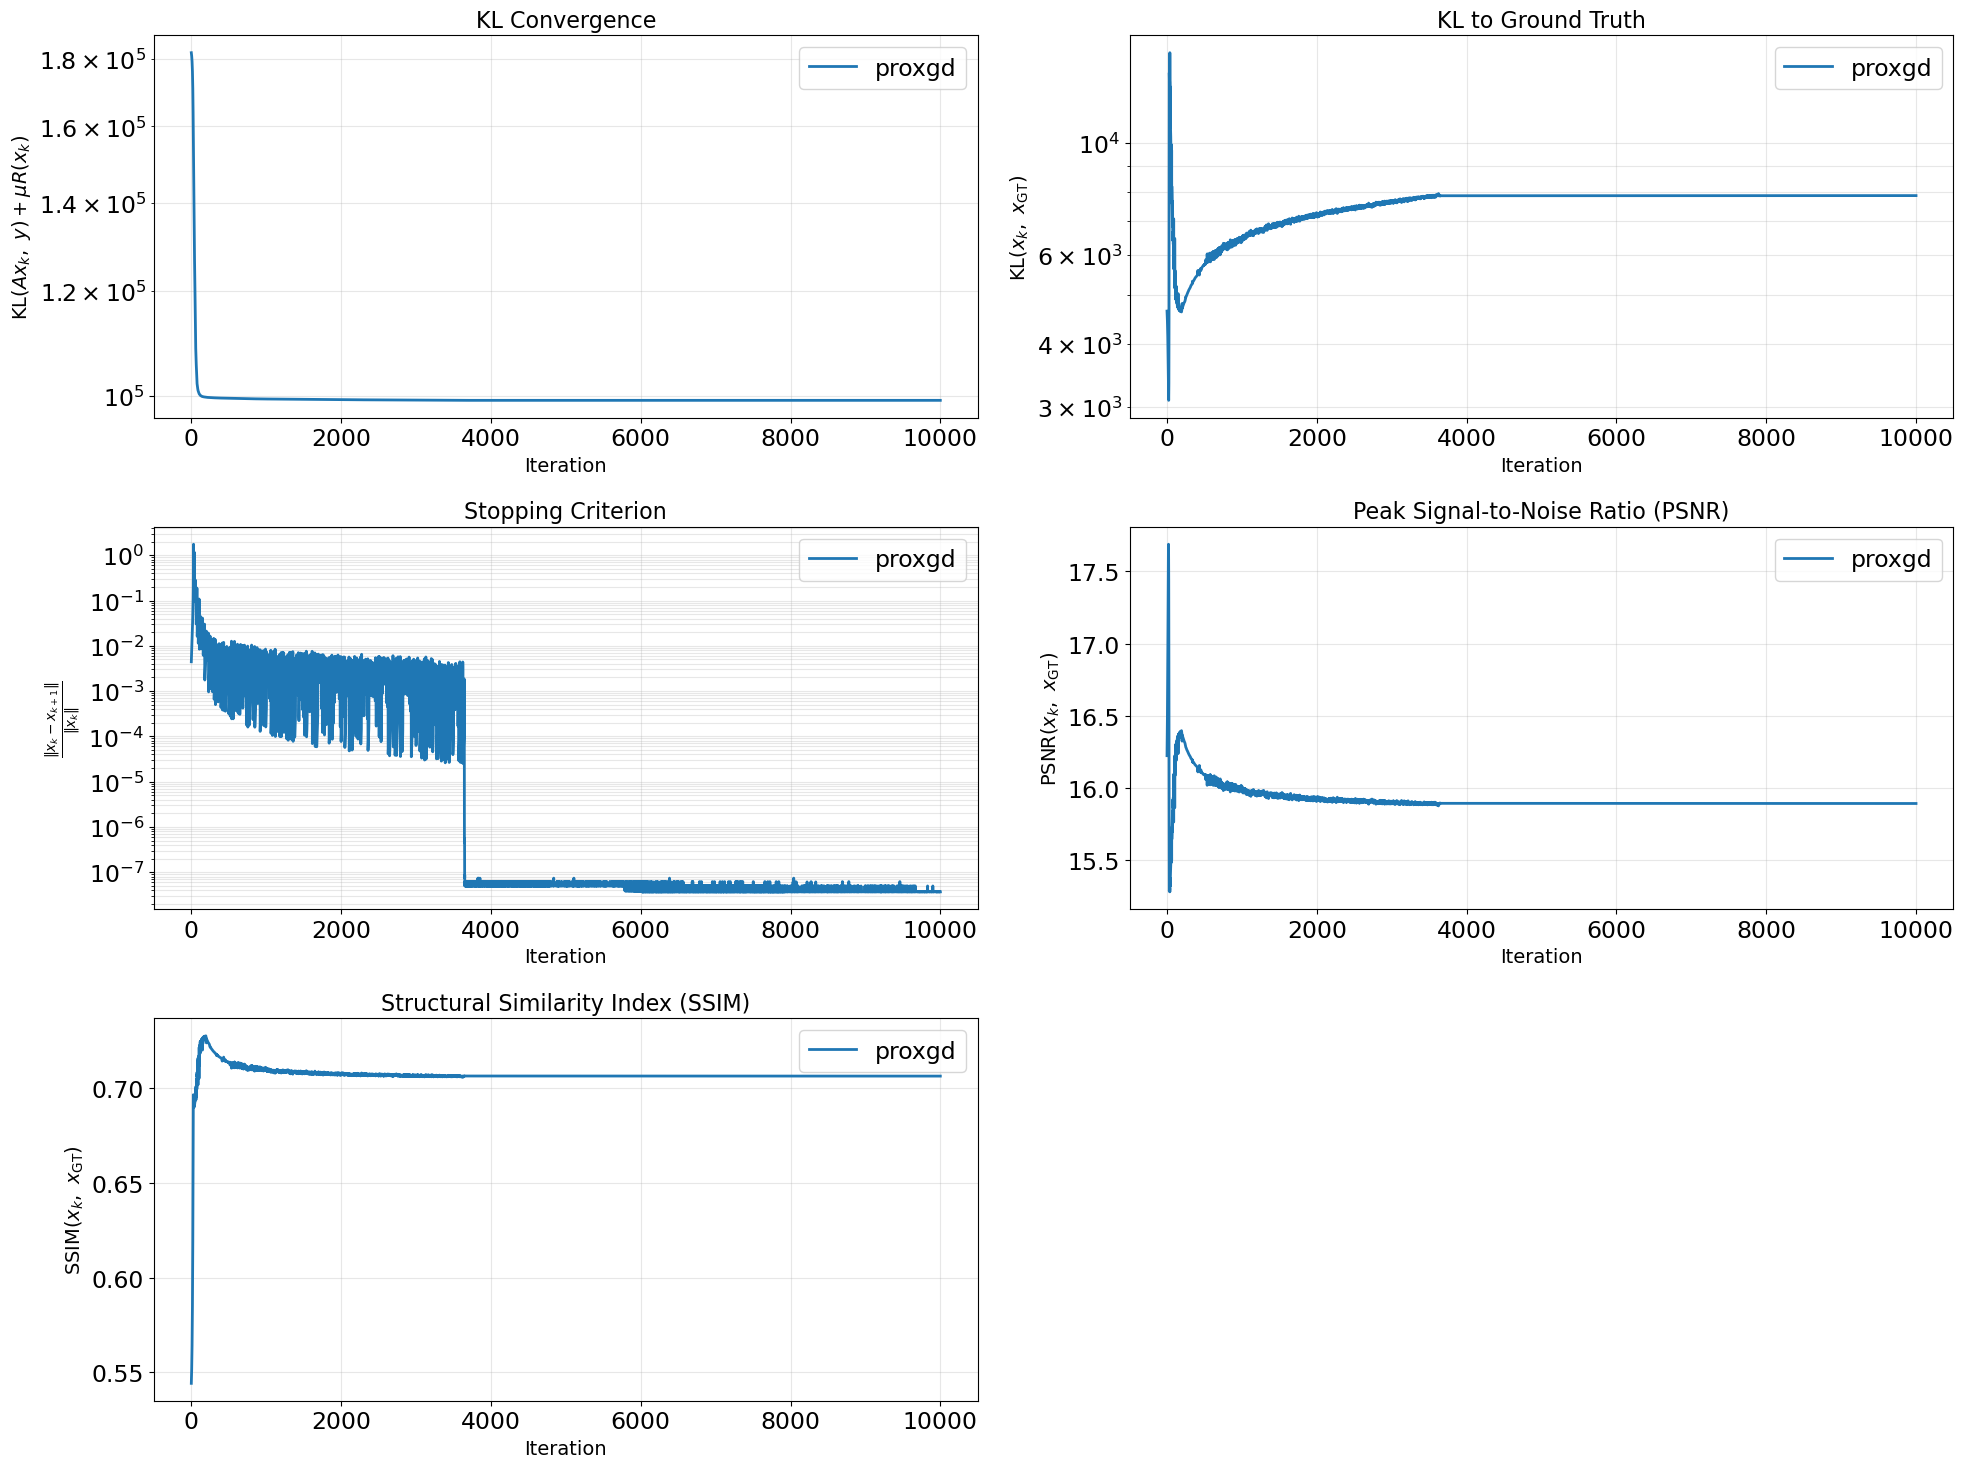

PSNR 15.89387035369873
SSIM 0.7063987255096436
MICROSSIM 0.7763366306649828


In [8]:
lam_to_load = 0.0505

algo_to_load = "md"                # pgd or prox or md
name_to_load = "tubulin"     # tubulin for sim
sect_to_load = "2D"                 # 3D or 2D
real_to_load = "sim"               # real o sim

path = f"Results/ism_results/ism_l1_{sect_to_load}_{real_to_load}_{algo_to_load}_{name_to_load}_lam{lam_to_load}.pth"
# path = "Results/ism_results/ism_tv_3D_sim_md_tubulin_lam0.05152.pth"

checkpoint = torch.load(path, weights_only = False)
results = checkpoint['results']
dataset = checkpoint['dataset']
hparams = checkpoint['hparams']


plot_results(results, dataset, hparams['IS_REAL'], hparams['IS_3D'], hparams['pxsize'], x0_sec = 300, y0_sec = 250)

# kl_funct = results['diff_fid']

# # .numpy() assicura la compatibilità perfetta con Matplotlib
# plt.plot(kl_funct.cpu().numpy()) 

# plt.title("KL to Ground Truth")
# # Usare plt.xlabel e plt.ylabel (senza "set_")
# plt.xlabel("Iteration", fontsize=14)
# plt.ylabel(r"$\mathrm{KL}(x_k,\ x_{\mathrm{GT}})$", fontsize=14)

# plt.grid(True) # Opzionale, ma rende il grafico molto più leggibile
# plt.show()


In [ ]:
x = dataset["noise_image"]
x_gt = dataset["ground_truth"]
x = x[11:12] / x[11:12].max()
x_gt = x_gt / x_gt.max()
print(f"MICROSSIM {micro_structural_similarity(x_gt.squeeze().detach().cpu().numpy().astype(np.float32), x.squeeze().detach().cpu().numpy().astype(np.float32))}")

In [ ]:
x1 = results["x_result"][:,0:1]
x = results["x_result"][:,1:2]
x1_masked = x1[x1 != 0]

# Calculate the mean (and extract the Python float using .item())
mean_val = x1_masked.mean().item()

# Get the total number of pixels in a PyTorch Tensor
total_pixels = x.numel()

# Count how many pixels are strictly below the mean
# .item() extracts the single integer from the resulting 0D tensor
num_below_mean = (x < 5).sum().item()

# Calculate the percentage
percentage_below_mean = (num_below_mean / total_pixels) * 100

print(f"Mean value: {mean_val:.4f}")
print(f"Number of pixels below mean: {num_below_mean} out of {total_pixels}")
print(f"Percentage of pixels below mean: {percentage_below_mean:.2f}%")

In [ ]:
x1 = results["x_result"][:,0:1]
x = results["x_result"][:,1:2]

x1_masked = x1[x1 != 0]

# Calcola la media dell'immagine di riferimento (x1)
mean_val = x1_masked.mean().item()

# Crea una maschera logica per i pixel non neri (strettamente maggiori di 0, o != 0)
mask_non_zero = x != 0

# Calcola il numero totale di pixel VALIDI (non neri) in x
total_valid_pixels = mask_non_zero.sum().item()

# Conta quanti pixel NON NERI sono anche SOTTO LA MEDIA di x1
# Usiamo l'operatore bitwise & per combinare le due condizioni
num_below_mean = (mask_non_zero & (x < mean_val)).sum().item()

# Calcola la percentuale (con un piccolo controllo per evitare divisioni per zero)
if total_valid_pixels > 0:
    percentage_below_mean = (num_below_mean / total_valid_pixels) * 100
else:
    percentage_below_mean = 0.0

print(f"Media di riferimento (da x1): {mean_val:.4f}")
print(f"Numero di pixel totali nell'immagine: {x.numel()}")
print(f"Numero di pixel NON neri in x: {total_valid_pixels}")
print(f"Pixel non neri sotto la media: {num_below_mean} su {total_valid_pixels}")
print(f"Percentuale (calcolata solo sui pixel attivi): {percentage_below_mean:.2f}%")

# WHITE PRINCIPLE

5.05e-02
--- Risultati per WP ---
Mu ottimale (min WP): 4.344000e-02 con WP = 2.005122e+00
Mu ottimale (max PSNR): 3.132000e-02 con PSNR = 16.0393 dB
Mu ottimale (max SSIM): 3.132000e-02 con SSIM = 0.7127



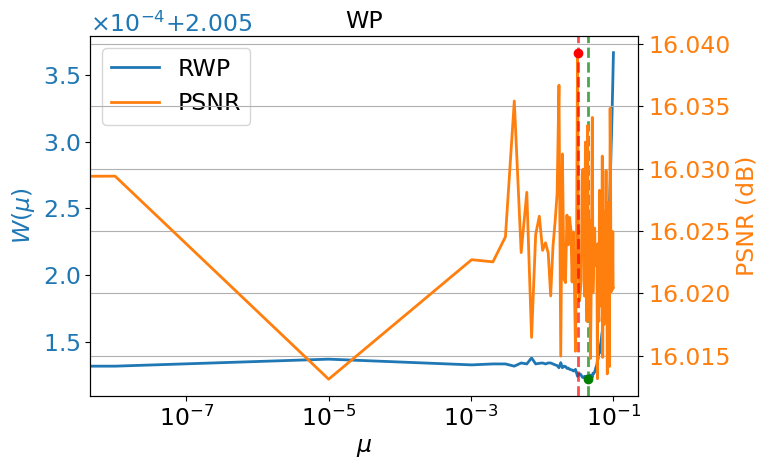

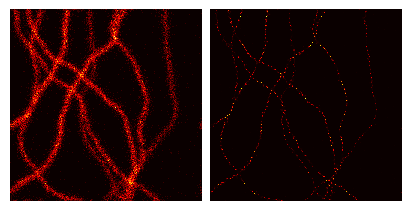

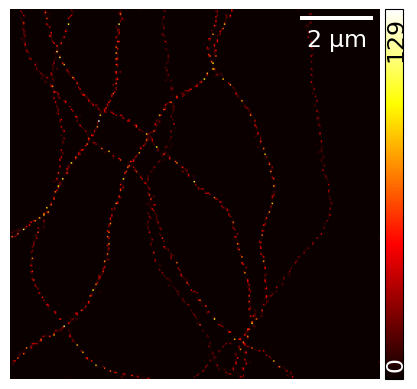

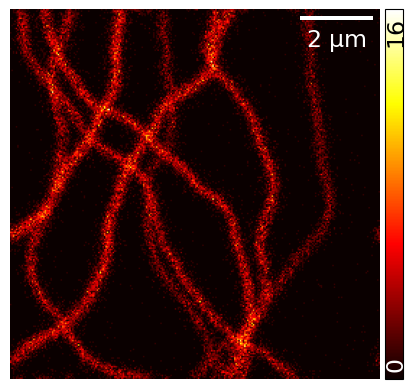

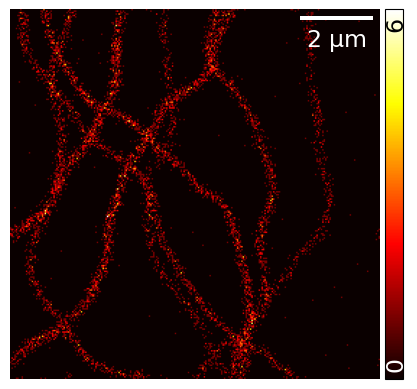

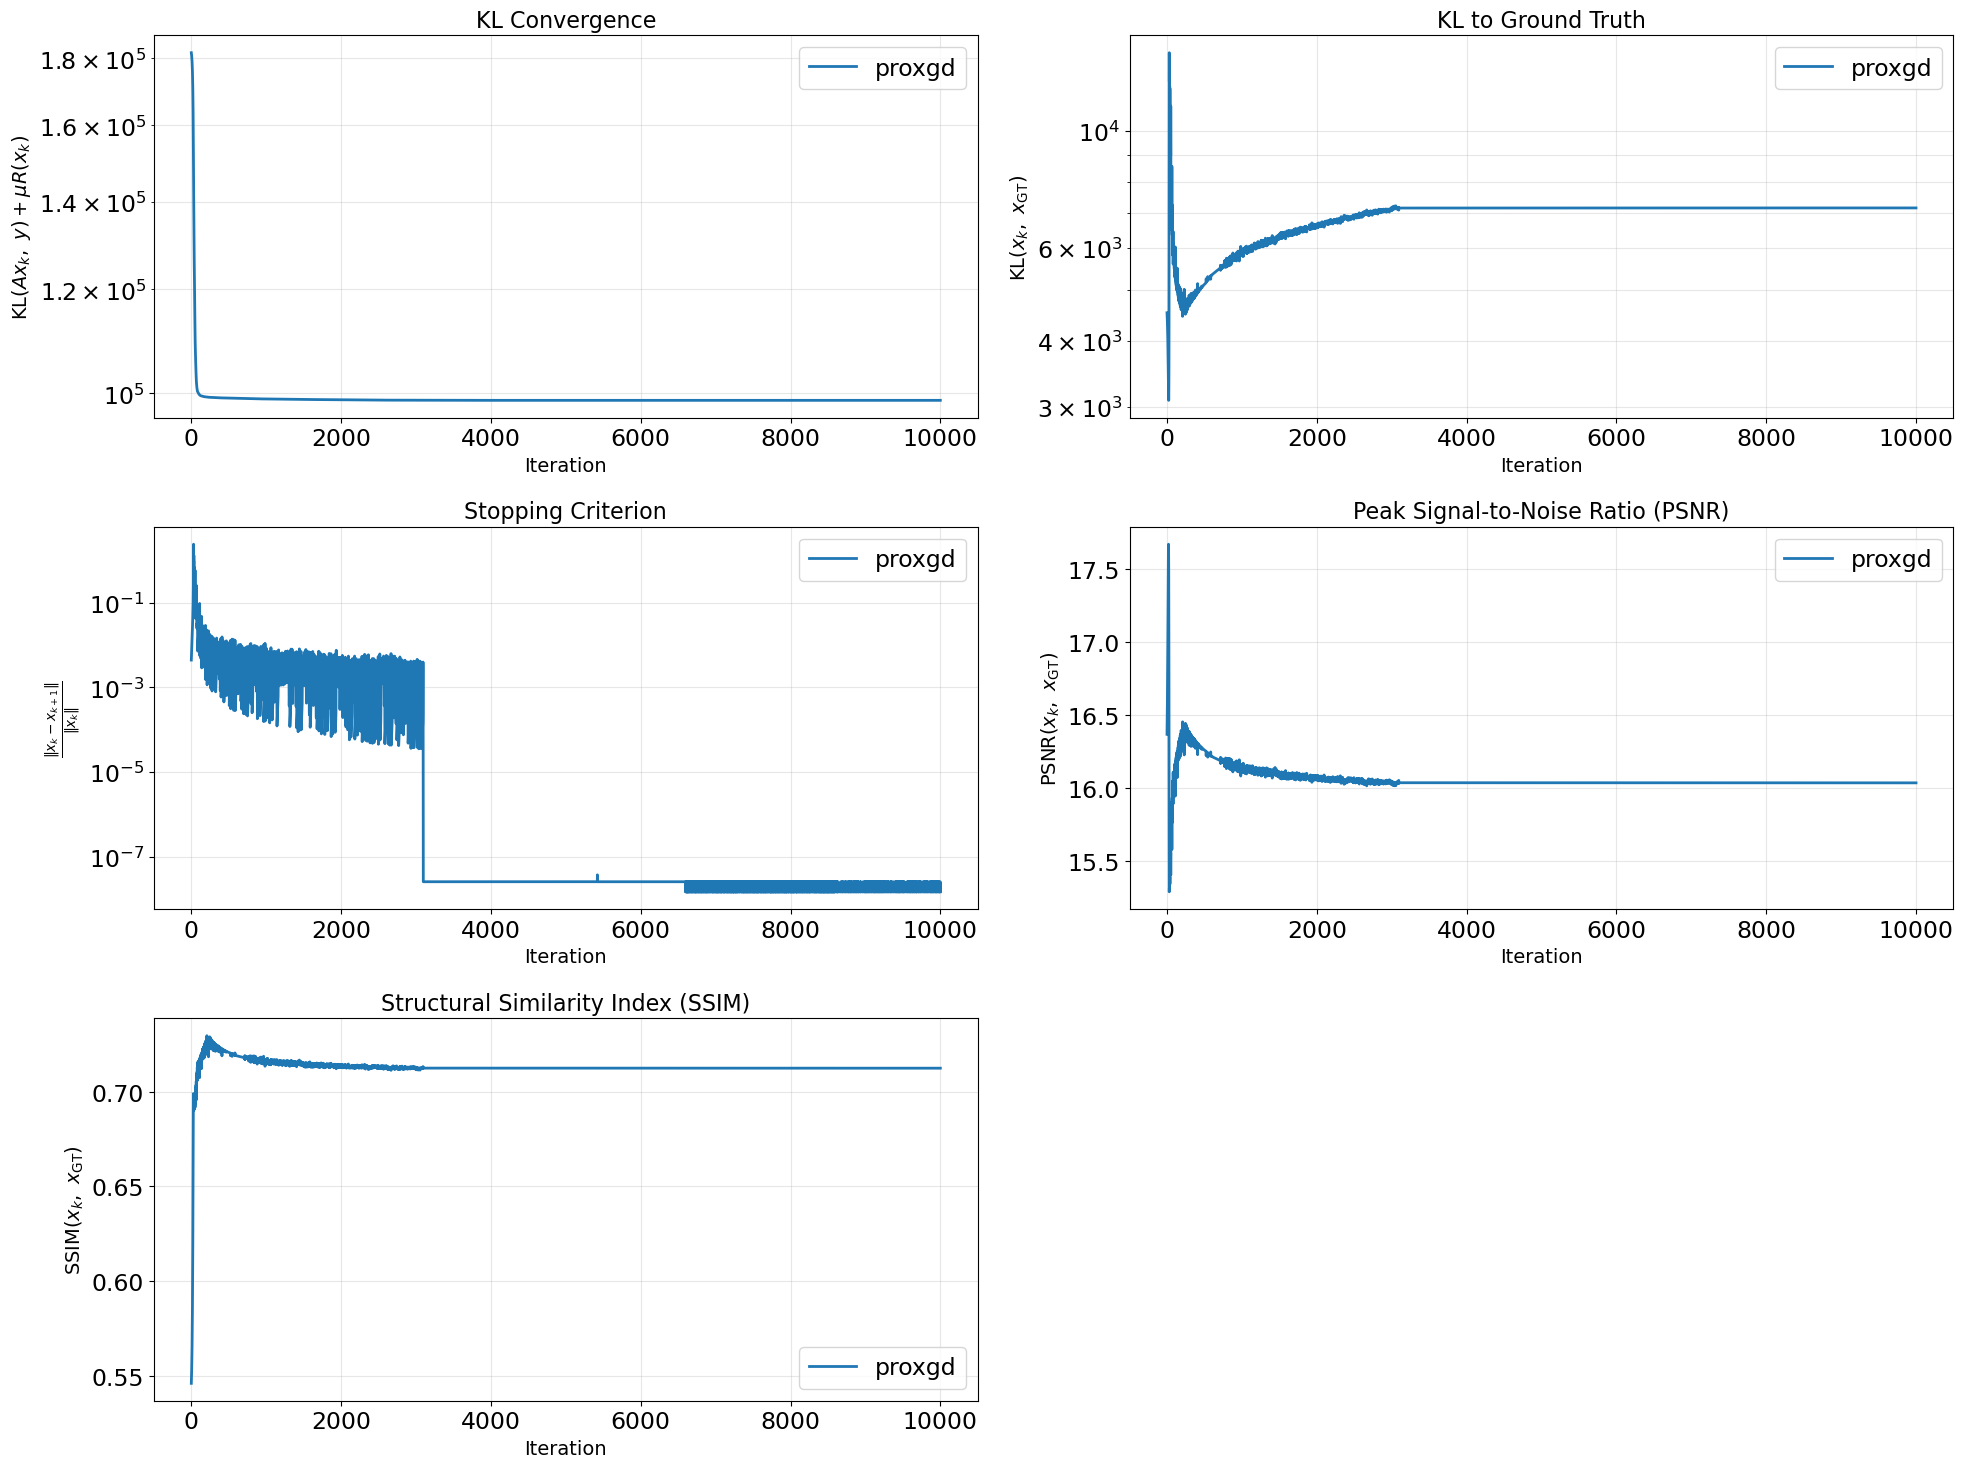

PSNR 16.03346061706543
SSIM 0.7124401330947876
MICROSSIM 0.7779528066807659


In [6]:
# path = "Results/WP/wp_3D_pgd_masked_06_convallaria.pth"
mask_type = 'masked'                # whole, masked, masked_eps
algo_to_load = "md"                # pgd or prox or md
name_to_load = "tubulin"            # tubulin for sim 05_convallaria
sect_to_load = "2D"                 # 3D or 2D

path = f"Results/WP/wp_l1_{sect_to_load}_{algo_to_load}_{mask_type}_{name_to_load}.pth"

checkpoint = torch.load(path, weights_only = False)
results = checkpoint['results']
dataset = checkpoint['dataset']
hparams = checkpoint['hparams']

best_mu = find_knee_point(hparams['mu_grid'].cpu(),results['W_sum'].cpu())
print("{:.2e}".format(best_mu))

plot_wp_results(hparams['mu_grid'], results, dataset, hparams['pxsize'], is_real= hparams['IS_REAL'], is_3d = hparams['IS_3D'], title="WP", layout="twin", x0 = 100, y0 = 100)

results_best = results['results_best']
# kl_funct = results_best['diff']

# .numpy() assicura la compatibilità perfetta con Matplotlib
# plt.plot(kl_funct.cpu().numpy()) 

# plt.title("KL to Ground Truth")
# # Usare plt.xlabel e plt.ylabel (senza "set_")
# plt.xlabel("Iteration", fontsize=14)
# plt.ylabel(r"$\mathrm{KL}(x_k,\ x_{\mathrm{GT}})$", fontsize=14)

# plt.grid(True) # Opzionale, ma rende il grafico molto più leggibile

# plt.show()




In [12]:
results.keys()

dict_keys(['W_sum', 'psnr_vecs', 'ssim_vecs', 'results_best', 'wh_true', 'ground_truth'])

In [ ]:
## utilizzo


tensor(0.0010)


In [4]:
# path = "Results/WP/wp_3D_pgd_masked_06_convallaria.pth"
mask_type = 'masked'                # whole, masked, masked_eps
name_to_load = "02_tomm20"            # tubulin for sim 05_convallaria
sect_to_load = "3D"                 # 3D or 2D

algo_to_load = "pgd"                # pgd or prox or md
path_tv = f"Results/WP/wp_{sect_to_load}_{algo_to_load}_{mask_type}_{name_to_load}.pth"

checkpoint_tv = torch.load(path_tv, weights_only = False)
results_tv = checkpoint_tv['results']

results_best_tv = results_tv['results_best']
x_result_tv = results_best_tv['x_result']
x_result_tv = x_result_tv.cpu()
noise_image = dataset["noise_image"].cpu()

meta = dataset['meta']
clabel = meta.pxdwelltime

algo_to_load = "prox"                # pgd or prox or md
path_l1 = f"Results/WP/wp_{sect_to_load}_{algo_to_load}_{mask_type}_{name_to_load}.pth"

checkpoint_l1 = torch.load(path_l1, weights_only = False)
results_l1 = checkpoint_l1['results']
results_best_l1 = results_l1['results_best']
x_result_l1 = results_best_l1['x_result']
x_result_l1 = x_result_l1.cpu()

algo_to_load = "md"                # pgd or prox or md
path_md = f"Results/WP/wp_{sect_to_load}_{algo_to_load}_{mask_type}_{name_to_load}.pth"
checkpoint_md = torch.load(path_md, weights_only = False)
results_md = checkpoint_md['results']
results_best_md = results_md['results_best']
x_result_md = results_best_md['x_result']
x_result_md = x_result_md.cpu()


lam_to_load = 0
real_to_load = "real"               # real o sim
algo_to_load = "pgd"                # pgd or prox or md

path = f"Results/ism_results/ism_{sect_to_load}_{real_to_load}_{algo_to_load}_{name_to_load}_lam{lam_to_load}.pth"
# path = "Results/ism_results/ism_tv_3D_sim_md_tubulin_lam0.05152.pth"

checkpoint = torch.load(path, weights_only = False)
results_noreg = checkpoint['results']
x_result_noreg = results_noreg['x_result'].cpu()

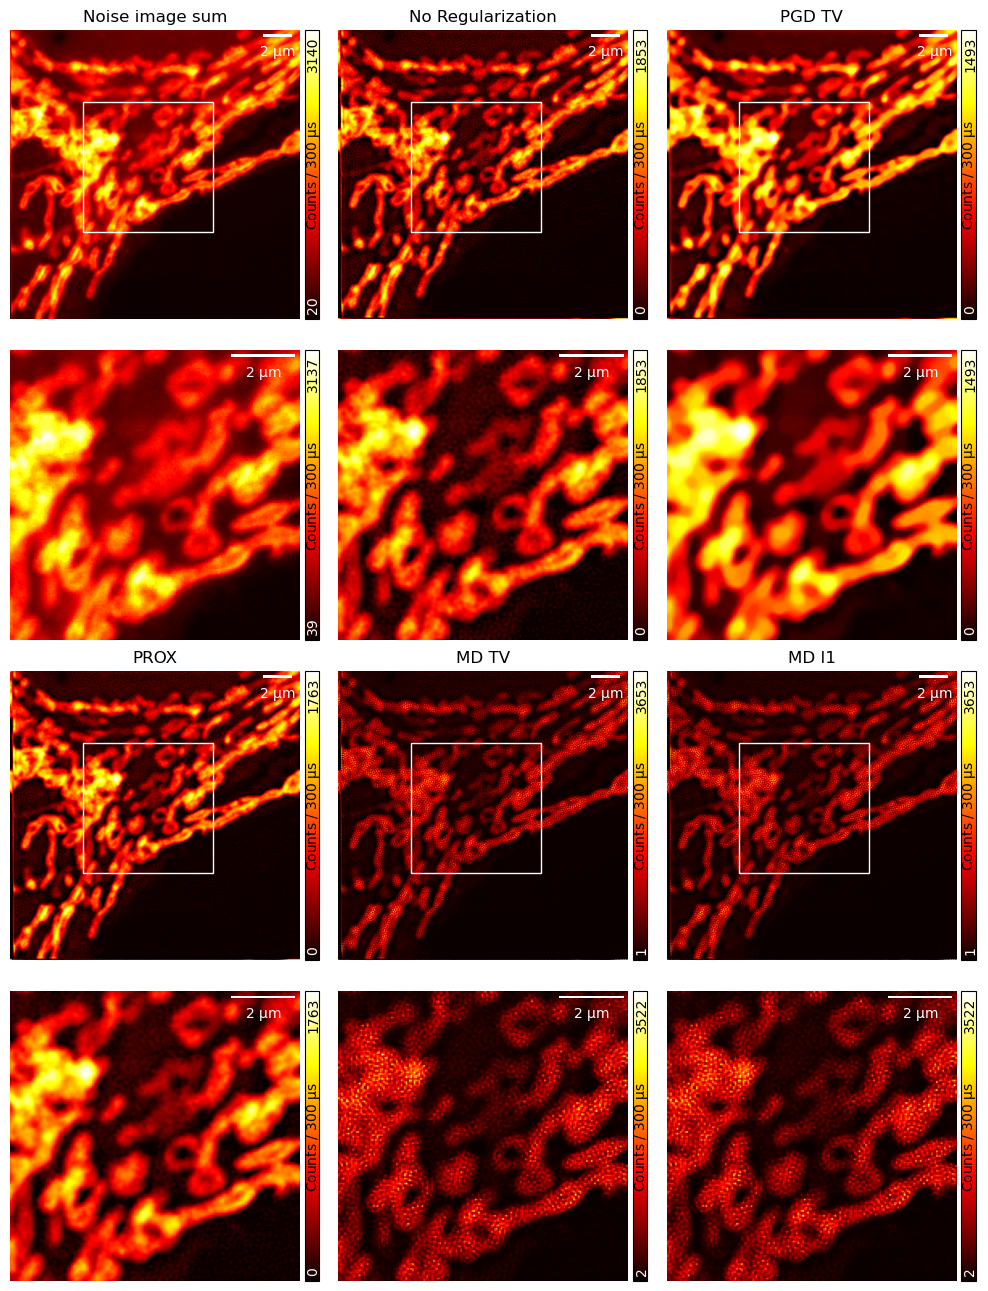

In [78]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 4 righe x 3 colonne
fig, ax = plt.subplots(4, 3, sharex='row', sharey='row', figsize=(10, 13))

x0 = 100
y0 = 100
dx = 180
dy = 180

def get_rect():
    return patches.Rectangle((y0, x0), dy, dx, linewidth=1, edgecolor='w', facecolor='none')

# ==========================================
# --- PARTE SUPERIORE (Righe 0 e 1) ---
# ==========================================

# --- 1. Top Left: Noise ---
gr.ShowImg(noise_image[:,:,:, :].sum(0), meta.dx, clabel, fig=fig, ax=ax[0,0])
gr.ShowImg(noise_image[:,:,x0:x0+dx, y0:y0+dx].sum(0), meta.dx, clabel, fig=fig, ax=ax[1,0])
ax[0,0].add_patch(get_rect()) 
ax[0,0].set_title("Noise image sum")

# --- 2. Top Center: No Regularization ---
gr.ShowImg(x_result_noreg[:,1:2,:, :].sum(0), meta.dx, clabel, fig=fig, ax=ax[0,1])
gr.ShowImg(x_result_noreg[:,1:2,x0:x0+dx, y0:y0+dx].sum(0), meta.dx, clabel, fig=fig, ax=ax[1,1])
ax[0,1].add_patch(get_rect())
ax[0,1].set_title("No Regularization")

# --- 3. Top Right: PGD (TV) ---
gr.ShowImg(x_result_tv[:,1:2,:, :], meta.dx, clabel, fig=fig, ax=ax[0,2])
gr.ShowImg(x_result_tv[:,1:2,x0:x0+dx, y0:y0+dx], meta.dx, clabel, fig=fig, ax=ax[1,2])
ax[0,2].add_patch(get_rect()) 
ax[0,2].set_title("PGD TV")


# ==========================================
# --- PARTE INFERIORE (Righe 2 e 3) ---
# ==========================================

# --- 4. Bottom Left: PROX (L1) ---
gr.ShowImg(x_result_l1[:,1:2,:, :].sum(0), meta.dx, clabel, fig=fig, ax=ax[2,0])
gr.ShowImg(x_result_l1[:,1:2,x0:x0+dx, y0:y0+dx].sum(0), meta.dx, clabel, fig=fig, ax=ax[3,0])
ax[2,0].add_patch(get_rect())
ax[2,0].set_title("PROX")

# --- 5. Bottom Center: Mirror Descent (MD) ---
gr.ShowImg(x_result_md[:,1:2,:, :], meta.dx, clabel, fig=fig, ax=ax[2,1])
gr.ShowImg(x_result_md[:,1:2,x0:x0+dx, y0:y0+dx], meta.dx, clabel, fig=fig, ax=ax[3,1])
ax[2,1].add_patch(get_rect()) 
ax[2,1].set_title("MD TV")

# --- 6. Bottom Right: BregProx (ATTENZIONE ALLA VARIABILE) ---
# Ho cambiato x_result_noreg in x_result_breg per non farti plottare due volte la stessa cosa.
# Se non si chiama così nel tuo codice, ricordati di aggiornarla!
gr.ShowImg(x_result_md[:,1:2,:, :].sum(0), meta.dx, clabel, fig=fig, ax=ax[2,2])
gr.ShowImg(x_result_md[:,1:2,x0:x0+dx, y0:y0+dx].sum(0), meta.dx, clabel, fig=fig, ax=ax[3,2])
ax[2,2].add_patch(get_rect()) 
ax[2,2].set_title("MD l1")

fig.tight_layout()

# OPTIM WP

In [9]:
# path = "Results/WP/wp_3D_pgd_masked_06_convallaria.pth"
mask_type = 'masked'                 # whole, masked, masked_eps
algo_to_load = "pgd"                # pgd or prox or md
name_to_load = "02_tomm20"     # tubulin for sim
sect_to_load = "3D"                 # 3D or 2D

path = f"Results/WP/wp_optim_{sect_to_load}_{algo_to_load}_{mask_type}_{name_to_load}.pth"


checkpoint = torch.load(path, weights_only = False)
results = checkpoint['results_optim']
best_result = results['results_best']
dataset = checkpoint['dataset']
hparams = checkpoint['hparams']


print(f" Miglior mu trovato: {results['best_mu']:.6f} con RWP = {results['rwp_vec'].min():.4f}")

plt.plot(results['rwp_vec'][100:].cpu())

plot_results(best_result, dataset, hparams['IS_REAL'], hparams['IS_3D'], hparams['pxsize'], x0_sec = 100, y0_sec = 100)


FileNotFoundError: [Errno 2] No such file or directory: 'Results/WP/wp_optim_3D_pgd_masked_02_tomm20.pth'